# Empirical Example for Sensitivity Analysis: 401(k) Eligibility and Financial Wealth

This is an adaptation of the replication package for Chernozhukov, Cinelli, Newey, Sharma and Syrgkanis,
*Long Story Short: Omitted Variable Bias in Causal Machine Learning*

The original replication package can be found __[here](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/VH6QHQ)__.

This Python notebook uses `rpy2` to call the R `dml.sensemakr` package, which implements the DML estimation and CCNSS sensitivity analysis framework. The group ATE plots are reproduced in matplotlib; contour plots render directly from R via rpy2.

In [20]:
try:
    import rpy2
except ImportError:
    !pip install rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [21]:
%%R
repos <- c(CRAN = "https://cloud.r-project.org")
if (!requireNamespace("remotes",     quietly=TRUE)) install.packages("remotes",     repos=repos)
if (!requireNamespace("sensemakr",   quietly=TRUE)) install.packages("sensemakr",   repos=repos)
if (!requireNamespace("ggplot2",     quietly=TRUE)) install.packages("ggplot2",     repos=repos)
if (!requireNamespace("ranger",      quietly=TRUE)) install.packages("ranger",      repos=repos)
if (!requireNamespace("dml.sensemakr", quietly=TRUE)) {
  remotes::install_github("carloscinelli/dml.sensemakr", upgrade="never")
}

In [22]:
%%R
suppressMessages({
  library(sensemakr)
  library(dml.sensemakr)
  library(ggplot2)
})
options(scipen=99, repr.plot.width=5, repr.plot.height=5, repr.plot.res=150)

data("pension")

y <- pension$net_tfa
d <- pension$e401
x <- model.matrix(~ -1 + age + inc + educ + fsize + marr + twoearn + pira + hown,
                   data=pension)

cat("households:", nrow(x), " covariates:", ncol(x),
    " eligible:", sprintf("%.1f%%", 100*mean(d)), "\n")
cat("dml.sensemakr", as.character(packageVersion("dml.sensemakr")), "\n")

households: 9915  covariates: 8  eligible: 37.1% 
dml.sensemakr 0.2.2 


## Setting

The outcome $Y$ is net financial assets and the treatment $D$ is eligibility to enroll in a 401(k) plan. The observed covariates $X^o$ include income, age, education, family size, marital status, two-earner status, IRA participation, and home ownership.

The threat is that unobserved firm characteristics $A$ may affect both eligibility and financial assets through employer matching policies. Conditional ignorability holds given the full $X = (X^o, A)$, while the data identify only the short parameter $\theta_s$. The task is to bound its distance from the causal target $\theta$.

## Short Estimates Under Conditional Ignorability

### Partially Linear Model

The first specification is the partially linear model $Y = \theta_s D + f_s(X^o) + \varepsilon$, with nuisance functions modeled by random forests, cross-fitted over five folds and repeated five times.

In [23]:
%%R
set.seed(1)
dml.401k.plm <- dml(y, d, x, model="plm", cf.folds=5, cf.reps=5, verbose=FALSE)
summary(dml.401k.plm)


Debiased Machine Learning

 Model: Partially Linear 
 Cross-Fitting: 5 folds, 5 reps 
 ML Method: outcome (yreg0:ranger, yreg1:ranger, R2 = 26.474%), treatment (ranger, R2 = 11.599%)
 Tuning: dirty 

Average Treatment Effect : 

    Estimate Std. Error t value          P(>|t|)    
ate     9114       1323   6.888 0.00000000000567 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Note: DML estimates combined using the median method.

Verbal interpretation of DML procedure:

-- Average treatment effects were estimated using DML with 5-fold cross-fitting. In order to reduce the variance that stems from sample splitting, we repeated the procedure 5 times. Estimates are combined using the median as the final estimate, incorporating variation across experiments into the standard error as described in Chernozhukov et al. (2018). The outcome regression uses Random Forest from the R package ranger; the treatment regression uses Random Forest from the R package ranger.

### Nonparametric Model, with Income Groups

The second specification drops the additive structure and targets $\theta_s = \mathrm{E}\{g_s(1,X^o) - g_s(0,X^o)\}$ with the same nuisance learners.

In [24]:
%%R
g1 <- cut(x[,"inc"],
          quantile(x[,"inc"], c(0,.25,.5,.75,1), na.rm=TRUE),
          labels=c("q1","q2","q3","q4"), include.lowest=TRUE)

set.seed(1)
dml.401k.npm <- dml(y, d, x, groups=g1, model="npm",
                    cf.folds=5, cf.reps=5, verbose=FALSE)
summary(dml.401k.npm)


Debiased Machine Learning

 Model: Nonparametric 
 Cross-Fitting: 5 folds, 5 reps 
 ML Method: outcome (yreg0:ranger, yreg1:ranger, R2 = 25.572%), treatment (ranger, R2 = 11.48%)
 Tuning: dirty 

Average Treatment Effect : 

    Estimate Std. Error t value          P(>|t|)    
ate     8198       1196   6.852 0.00000000000726 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Group Average Treatment Effect: 

         Estimate Std. Error t value       P(>|t|)    
g.ate.q1   4646.2      794.2   5.850 0.00000000492 ***
g.ate.q2   2729.4     1296.7   2.105      0.035305 *  
g.ate.q3   6854.3     1838.0   3.729      0.000192 ***
g.ate.q4  18406.6     4061.6   4.532 0.00000584674 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Note: DML estimates combined using the median method.

Verbal interpretation of DML procedure:

-- Average treatment effects were estimated using DML with 5-fold cross-fitting. In order to reduce the variance that stems fro

## Group Effects by Income Quartile

In [25]:
%%R -o group_est -o lwr_ci -o upr_ci
group.names <- setdiff(names(coef(dml.401k.npm)), "ate")
group_est   <- coef(dml.401k.npm)[group.names]
group_cis   <- confint(dml.401k.npm)[group.names, ]
lwr_ci      <- group_cis[, 1]
upr_ci      <- group_cis[, 2]

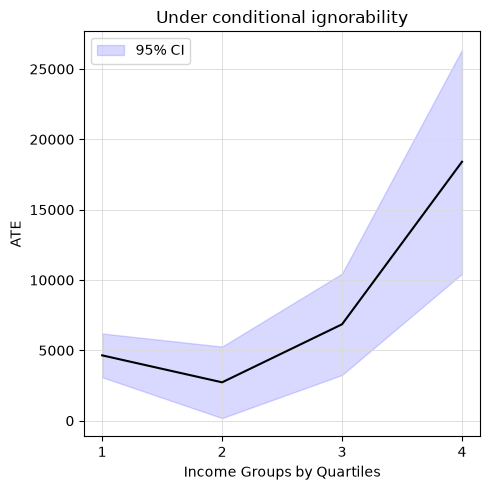

In [26]:
import numpy as np
import matplotlib.pyplot as plt

groups = np.arange(1, 5)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(groups, group_est, color="black")
ax.fill_between(groups, lwr_ci, upr_ci, alpha=0.15, color="blue", label="95% CI")
ax.set_xticks(groups)
ax.set_xlabel("Income Groups by Quartiles")
ax.set_ylabel("ATE")
ax.set_title("Under conditional ignorability")
ax.legend()
ax.grid(color="0.85", linewidth=0.6)
plt.tight_layout()
plt.show()

In [27]:
%%R
rv.plm <- robustness_value(dml.401k.plm)
rv.npm <- robustness_value(dml.401k.npm)
cat(sprintf(
  "RV_alpha (alpha=0.05, threshold theta=0)\n  partially linear: %.1f%%\n  nonparametric  : %.1f%%\n",
  100*rv.plm["ate"], 100*rv.npm["ate"]))

RV_alpha (alpha=0.05, threshold theta=0)
  partially linear: 5.6%
  nonparametric  : 4.6%


## The Main Confounding Scenario

The main scenario assumes $C_Y^2 = 0.04$ (outcome variation from unobserved firm characteristics equivalent to three years of maximum employer match), $q_\alpha \approx 0.03$ on the treatment side, and $|\rho| = 1$ (worst-case alignment).

In [28]:
%%R
cf.y  <- 0.04
cf.d  <- 0.03
rho2  <- 1

bounds.plm <- dml_bounds(dml.401k.plm, cf.y=cf.y, cf.d=cf.d, rho2=rho2)
bounds.npm <- dml_bounds(dml.401k.npm, cf.y=cf.y, cf.d=cf.d, rho2=rho2)
cb.plm     <- confidence_bounds(dml.401k.plm, cf.y=cf.y, cf.d=cf.d, rho2=rho2)
cb.npm     <- confidence_bounds(dml.401k.npm, cf.y=cf.y, cf.d=cf.d, rho2=rho2)

In [29]:
%%R -o plm_ts -o plm_bb -o plm_tm -o plm_tp -o plm_cbl -o plm_cbu -o npm_ts -o npm_bb -o npm_tm -o npm_tp -o npm_cbl -o npm_cbu
plm_b <- coef(bounds.plm)[, "ate"]
plm_ts  <- plm_b["theta.s"];  plm_bb <- plm_b["bias.bound"]
plm_tm  <- plm_b["theta.m"];  plm_tp <- plm_b["theta.p"]
plm_cbl <- cb.plm["ate", 1]; plm_cbu <- cb.plm["ate", 2]

npm_b <- coef(bounds.npm)[, "ate"]
npm_ts  <- npm_b["theta.s"];  npm_bb <- npm_b["bias.bound"]
npm_tm  <- npm_b["theta.m"];  npm_tp <- npm_b["theta.p"]
npm_cbl <- cb.npm["ate", 1]; npm_cbu <- cb.npm["ate", 2]

In [30]:
import pandas as pd

def fmt(v): return f"${v:,.0f}"

table = pd.DataFrame({
    "Short ATE":        [fmt(plm_ts[0]), fmt(npm_ts[0])],
    "Bias bound":       [fmt(plm_bb[0]), fmt(npm_bb[0])],
    "ATE bounds":       [f"[{fmt(plm_tm[0])}, {fmt(plm_tp[0])}]",
                         f"[{fmt(npm_tm[0])}, {fmt(npm_tp[0])}]"],
    "95% conf. bounds": [f"[{fmt(plm_cbl[0])}, {fmt(plm_cbu[0])}]",
                         f"[{fmt(npm_cbl[0])}, {fmt(npm_cbu[0])}]"],
}, index=["Partially linear", "Nonparametric"])
table

,Short ATE,Bias bound,ATE bounds,95% conf. bounds
Partially linear,"$9,114","$4,201","[$4,918, $13,311]","[$2,725, $15,573]"
Nonparametric,"$8,198","$4,529","[$3,644, $12,752]","[$1,618, $14,805]"


### Group Effects Under the Scenario

The same income groups, now with sensitivity bounds (orange) and 95% confidence bounds (blue).

In [31]:
%%R -o lwr_bound -o upr_bound -o lwr_cbound -o upr_cbound
bds    <- confidence_bounds(dml.401k.npm, cf.y=cf.y, cf.d=cf.d, rho2=rho2, level=0)
cbds   <- confidence_bounds(dml.401k.npm, cf.y=cf.y, cf.d=cf.d, rho2=rho2, level=0.95)
lwr_bound  <- bds[group.names,  1]
upr_bound  <- bds[group.names,  2]
lwr_cbound <- cbds[group.names, 1]
upr_cbound <- cbds[group.names, 2]

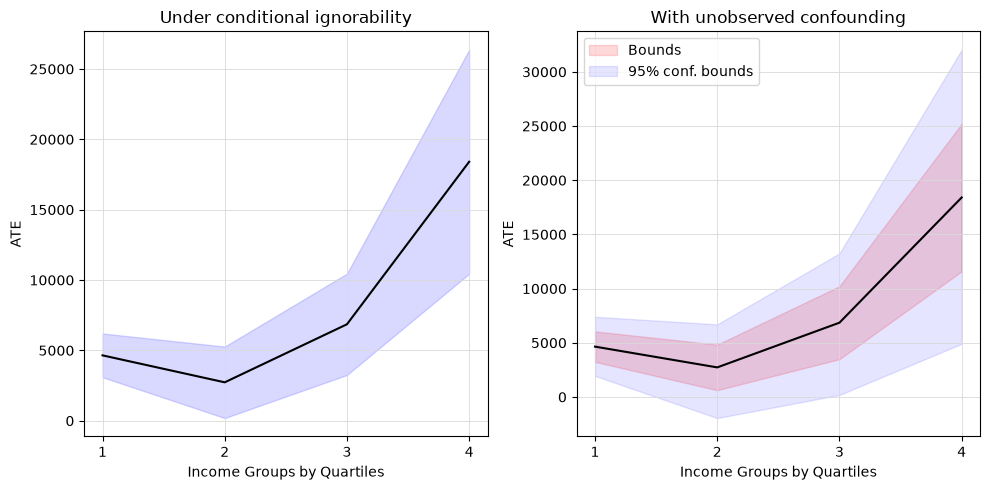

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: under ignorability
ax = axes[0]
ax.plot(groups, group_est, color="black")
ax.fill_between(groups, lwr_ci, upr_ci, alpha=0.15, color="blue")
ax.set_xticks(groups); ax.set_xlabel("Income Groups by Quartiles")
ax.set_ylabel("ATE"); ax.set_title("Under conditional ignorability")
ax.grid(color="0.85", linewidth=0.6)

# Right: with confounding
ax = axes[1]
ax.plot(groups, group_est, color="black")
ax.fill_between(groups, lwr_bound,  upr_bound,  alpha=0.15, color="red",  label="Bounds")
ax.fill_between(groups, lwr_cbound, upr_cbound, alpha=0.10, color="blue", label="95% conf. bounds")
ax.set_xticks(groups); ax.set_xlabel("Income Groups by Quartiles")
ax.set_ylabel("ATE"); ax.set_title("With unobserved confounding")
ax.legend(); ax.grid(color="0.85", linewidth=0.6)

plt.tight_layout()
plt.show()

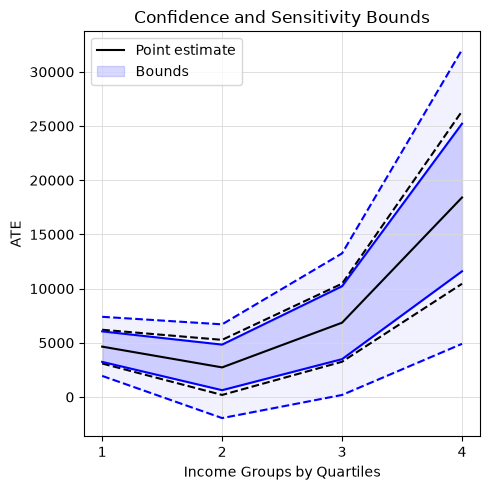

In [33]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(groups, group_est, color="black", label="Point estimate")
ax.plot(groups, lwr_ci,    color="black", linestyle="--")
ax.plot(groups, upr_ci,    color="black", linestyle="--")
ax.fill_between(groups, lwr_bound,  upr_bound,  alpha=0.15, color="blue", label="Bounds")
ax.fill_between(groups, lwr_cbound, upr_cbound, alpha=0.05, color="blue")
ax.plot(groups, lwr_bound,  color="blue")
ax.plot(groups, upr_bound,  color="blue")
ax.plot(groups, lwr_cbound, color="blue", linestyle="--")
ax.plot(groups, upr_cbound, color="blue", linestyle="--")
ax.set_xticks(groups)
ax.set_xlabel("Income Groups by Quartiles")
ax.set_ylabel("ATE")
ax.set_title("Confidence and Sensitivity Bounds")
ax.legend(); ax.grid(color="0.85", linewidth=0.6)
plt.tight_layout(); plt.show()

## Benchmarking

Rather than posit $C_Y$ and $C_D$ abstractly, we calibrate them against observed covariates. Dropping each covariate, refitting, and reading off the gains provides a reference scale.

In [34]:
%%R
set.seed(2)
invisible(capture.output(
  bench.plm <- dml_benchmark(dml.401k.plm,
                              benchmark_covariates=c("inc","pira","twoearn"))
))
out <- summary(bench.plm)$benchmarks

In [35]:
%%R -o bench_plm_r
bench_plm_r <- as.matrix(round(out[, c("gain.Y","gain.D","rho")], 4))

In [36]:
bench_df = pd.DataFrame(bench_plm_r,
                         columns=["gain.Y", "gain.D", "rho"],
                         index=["inc", "pira", "twoearn"])
print("PLM benchmarks:")
bench_df

PLM benchmarks:


,gain.Y,gain.D,rho
inc,0.1366,0.0502,-0.3372
pira,0.0487,0.0081,-0.1317
twoearn,0.0399,0.0112,0.2589


## Contour Plots

Contour plots of the lower 95% confidence bound on the ATE as a function of $(q_\alpha, C_Y^2)$. Benchmark points from the table above are overlaid.

In [37]:
%%R
ovb_contour_without_origin_label <- getS3method("ovb_contour_plot","dml")
plot_body <- as.list(body(ovb_contour_without_origin_label))
is_origin_label <- vapply(plot_body, function(expr)
  is.call(expr) && identical(expr[[1L]], as.name("text")) &&
  "label.unadjusted" %in% all.names(expr), logical(1))
stopifnot(sum(is_origin_label) == 1L)
plot_body[is_origin_label] <- list(quote(invisible(NULL)))
body(ovb_contour_without_origin_label) <- as.call(plot_body)

bumps.plm <- list(pira=c(0.010,0.009), twoearn=c(0.020,-0.002),
                   inc=c(0.010,0.009), inc4=c(0.015,-0.005))
bumps.npm <- list(pira=c(0.005,0.009), twoearn=c(0.020,0.005),
                   inc=c(-0.010,0.009), inc4=c(0.015,0.000))

contour_panel <- function(fit, bench_out, rho2, title, bumps=bumps.plm) {
  ovb_contour_without_origin_label(fit, which.bound="lwr", level=0.95,
    cf.y=NULL, rho2=rho2, col.contour="blue",
    label.bump.x=0.015, label.bump.y=0.003, lim.x=0.16)
  title(main=title)
  add_bound <- function(cfd, cfy, label, bx, by, ...) {
    sensemakr::add_bound_to_contour(r2dz.x=cfd, r2yz.dx=cfy,
      bound_label=label,
      bound_value=confidence_bounds(fit, cf.y=cfy, cf.d=cfd, rho2=rho2,
                                     level=0.95, combine.method="median")["ate","lwr"],
      label.bump.x=bx, label.bump.y=by, ...)
  }
  add_bound(0.03, 0.04, "Max Match",         0.015,  0.003, point.pch=25, point.bg="red")
  add_bound(bench_out["pira","gain.D"],   bench_out["pira","gain.Y"],   "1 x Part. in IRA",
            bumps$pira[1],   bumps$pira[2])
  add_bound(bench_out["twoearn","gain.D"],bench_out["twoearn","gain.Y"],"1 x Two Earners",
            bumps$twoearn[1],bumps$twoearn[2])
  add_bound(bench_out["inc","gain.D"],    bench_out["inc","gain.Y"],    "1 x Income",
            bumps$inc[1],    bumps$inc[2])
  add_bound(bench_out["inc","gain.D"]*0.25,bench_out["inc","gain.Y"]*0.25,"1/4 x Income",
            bumps$inc4[1],   bumps$inc4[2])
  add_bound(0, 0, "Unadjusted", 0.015, 0.003, point.pch=NA)
  invisible(NULL)
}

### Partially Linear Model

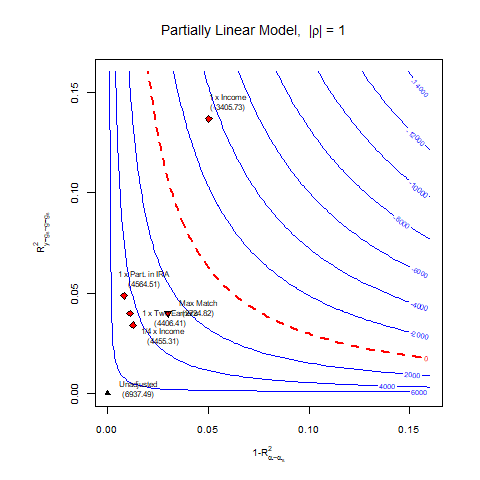

In [38]:
%%R
options(repr.plot.width=7, repr.plot.height=7)
contour_panel(dml.401k.plm, out, rho2=1,
              title=expression(paste("Partially Linear Model,  |",rho,"| = 1")))

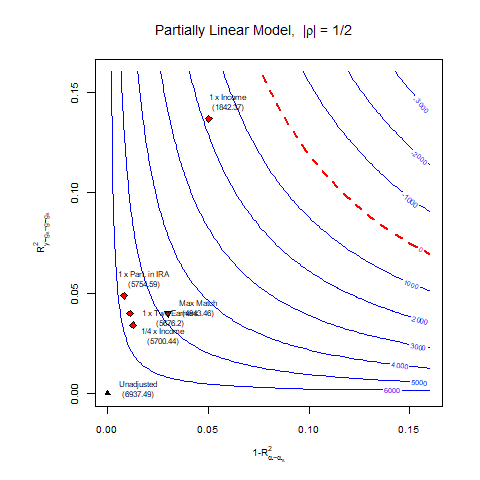

In [39]:
%%R
contour_panel(dml.401k.plm, out, rho2=(1/2)^2,
              title=expression(paste("Partially Linear Model,  |",rho,"| = 1/2")))

### Nonparametric Model

The nonparametric model requires separate benchmarks; `gain.D` here measures a relative gain in propensity-score precision.

In [40]:
%%R
set.seed(2)
invisible(capture.output(
  bench.npm <- dml_benchmark(dml.401k.npm,
                              benchmark_covariates=c("inc","pira","twoearn"))
))
out.npm <- summary(bench.npm)$benchmarks
round(out.npm[, c("gain.Y","gain.D","rho")], 4)

        gain.Y gain.D    rho
inc     0.1315 0.1288 -0.218
pira    0.0267 0.0000  0.000
twoearn 0.0113 0.0000  0.000


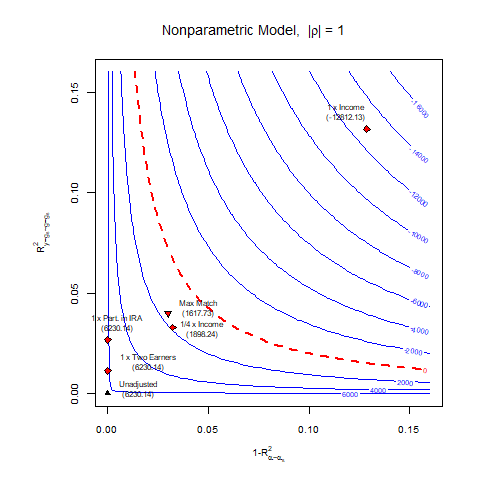

In [41]:
%%R
contour_panel(dml.401k.npm, out.npm, rho2=1, bumps=bumps.npm,
              title=expression(paste("Nonparametric Model,  |",rho,"| = 1")))

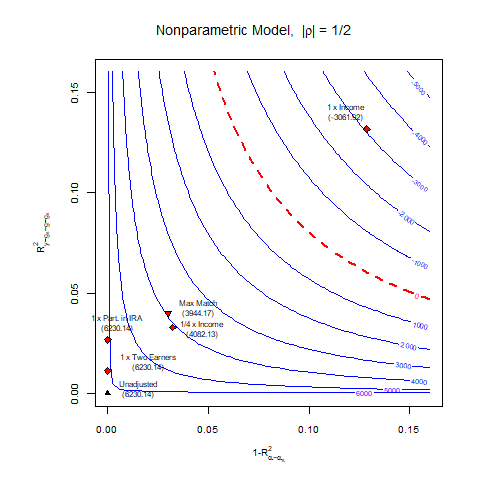

In [42]:
%%R
contour_panel(dml.401k.npm, out.npm, rho2=(1/2)^2, bumps=bumps.npm,
              title=expression(paste("Nonparametric Model,  |",rho,"| = 1/2")))

The nonparametric contours are slightly more conservative, but the message is similar. Under perfect adversarial alignment, income-strength confounding can overturn the finding; the contextual matching scenario cannot. At $|\rho| = 1/2$, the lower confidence endpoint for the main scenario remains comfortably positive.